# Validation


In [2]:
import rasterio
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


from rasterio.warp import reproject, Resampling
import os

base_path = os.path.expanduser("~/data/LEON_P6_forest-agri-change/")

# base_path = '/data/LEON_P6_forest-agri-change/'

## Load

In [96]:
# Tree height files
treeheight_dir = Path(base_path + "treeheight_predict")
years = [2019, 2020, 2021, 2022, 2023, 2024]

treeheight_data = {}
for year in years:
    treeheight_filepath = treeheight_dir / f"bugoma_treeheight_{year}_v10_cog.tif"
    with rasterio.open(treeheight_filepath) as src:
        treeheight_data[year] = src.read(1)  # Read first band
        print(f"Loaded {year}: shape {treeheight_data[year].shape}, CRS: {src.crs}")

# Forest extent file
forest_extent_path = Path(base_path + "forest_extent_bugoma_2020.tif")
with rasterio.open(forest_extent_path) as src:
    forest_extent = src.read(1)
    print(f"Loaded forest extent: shape {forest_extent.shape}, CRS: {src.crs}")

print("\nAll files loaded successfully!")

Loaded 2019: shape (1107, 1114), CRS: EPSG:32636
Loaded 2020: shape (1107, 1114), CRS: EPSG:32636
Loaded 2021: shape (1107, 1114), CRS: EPSG:32636
Loaded 2022: shape (1107, 1114), CRS: EPSG:32636
Loaded 2023: shape (1107, 1114), CRS: EPSG:32636
Loaded 2024: shape (1107, 1114), CRS: EPSG:32636
Loaded forest extent: shape (5284, 7508), CRS: EPSG:10793

All files loaded successfully!


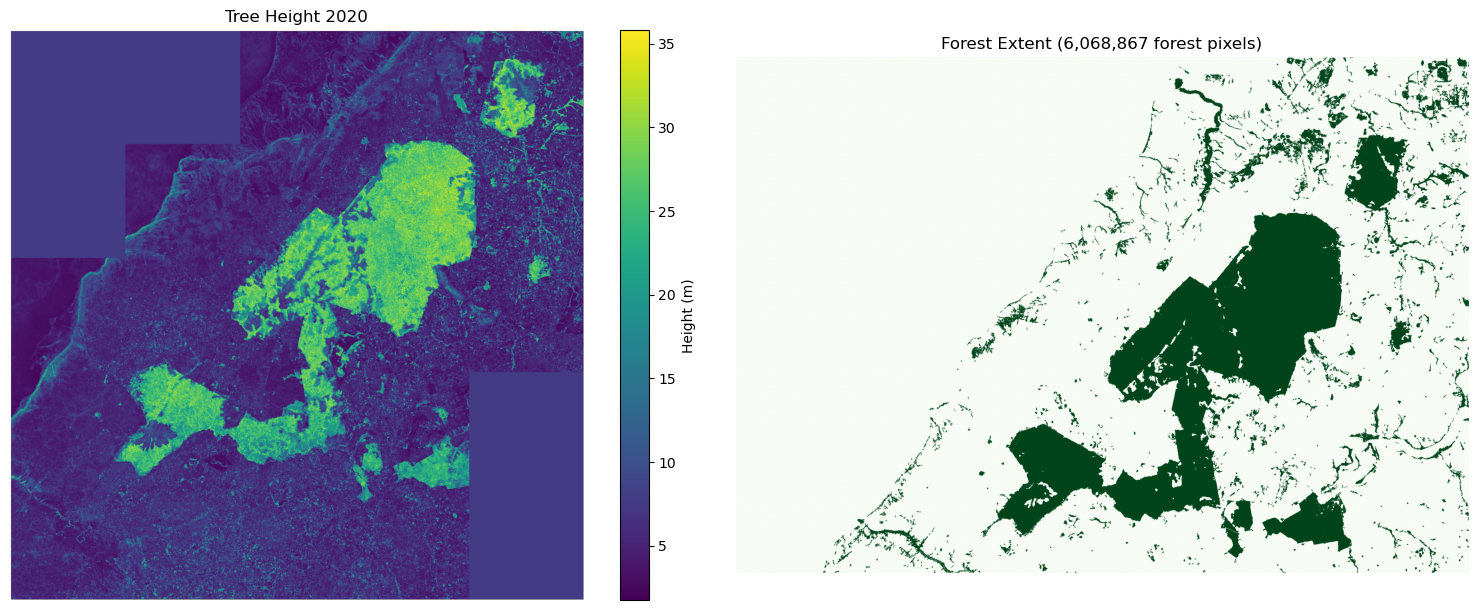

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Tree height
im1 = ax1.imshow(treeheight_data[2020], cmap='viridis')
ax1.set_title('Tree Height 2020')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, label='Height (m)')

# Forest extent binary
forest_binary = forest_extent > 0
im2 = ax2.imshow(forest_binary, cmap='Greens')
ax2.set_title(f'Forest Extent ({forest_binary.sum():,} forest pixels)')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Forest Baseline

In [98]:
from rasterio.warp import reproject, Resampling

# Resample forest extent to match tree height grid
with rasterio.open(treeheight_filepath) as src_th:
    with rasterio.open(forest_extent_path) as src_fe:
        forest_extent_resampled = np.empty(treeheight_data[2020].shape, dtype=src_fe.dtypes[0])
        
        reproject(
            source=rasterio.band(src_fe, 1),
            destination=forest_extent_resampled,
            src_transform=src_fe.transform,
            src_crs=src_fe.crs,
            dst_transform=src_th.transform,
            dst_crs=src_th.crs,
            resampling=Resampling.nearest
        )

# Create baseline
forest_baseline = (forest_extent_resampled > 0) #& (treeheight_data[2020] > 5)

print(f"Forest baseline pixels: {np.sum(forest_baseline):,}")

Forest baseline pixels: 227,236


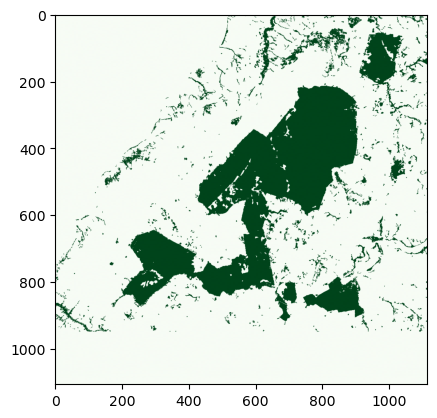

In [99]:
plt.imshow(forest_baseline, cmap='Greens')

## Deforestation progression from tree height

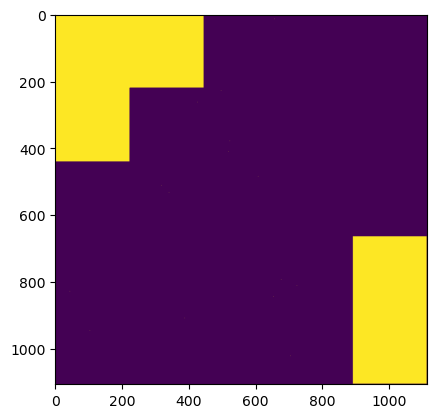

In [100]:
# Pixels to ignore everywhere (corners)

INVALID_VAL = 7.806812
TOL = 1e-6
invalid_mask = np.isclose(treeheight_data[2020], INVALID_VAL, atol=TOL)
plt.imshow(invalid_mask)

In [104]:
from scipy import ndimage

PIXEL_AREA_HA = 0.25   # 50m × 50m = 2500 m² = 0.25 ha
MIN_PATCH_HA  = 1.0
MIN_PATCH_PX  = int(np.ceil(MIN_PATCH_HA / PIXEL_AREA_HA))  # 4 pixels


def apply_forest_definition(mask):
    """Return mask with <1 ha patches removed."""
    labelled, _  = ndimage.label(mask)
    patch_sizes  = np.bincount(labelled.ravel())
    large_patches = patch_sizes >= MIN_PATCH_PX
    large_patches[0] = False
    return large_patches[labelled]

# --- Baseline with forest definition applied ---
raw_baseline    = (forest_extent_resampled > 0) & (~invalid_mask)
forest_baseline = apply_forest_definition(raw_baseline)

deforestation_map = np.zeros_like(treeheight_data[2020], dtype=int)
deforestation_map[forest_baseline] = 1

# --- Annual loop ---
defo_treeheight = 6 # <-- height threshold for deforestation
years = [2021, 2022, 2023, 2024]

for year in years:
    invalid_mask_year = np.isclose(treeheight_data[year], INVALID_VAL, atol=TOL)
    valid = ~invalid_mask_year

    # Current forest pool
    still_forest = (deforestation_map == 1)

    # Re-evaluate forest definition on remaining forest
    still_forest_valid = apply_forest_definition(still_forest)

    # Pixels that were forest but now fall below 1 ha patch threshold
    dropped_by_definition = still_forest & ~still_forest_valid
    deforestation_map[dropped_by_definition] = year - 2000

    # Height-based deforestation on definition-valid forest only
    height_dropped   = (treeheight_data[year] < defo_treeheight) & valid
    newly_deforested = still_forest_valid & height_dropped
    deforestation_map[newly_deforested] = year - 2000

    print(f"{year}: {np.sum(newly_deforested):,} px height-based deforested, "
          f"{np.sum(dropped_by_definition):,} px dropped by <1ha rule")

2021: 7,282 px height-based deforested, 0 px dropped by <1ha rule
2022: 8,113 px height-based deforested, 753 px dropped by <1ha rule
2023: 12,223 px height-based deforested, 762 px dropped by <1ha rule
2024: 6,783 px height-based deforested, 1,219 px dropped by <1ha rule


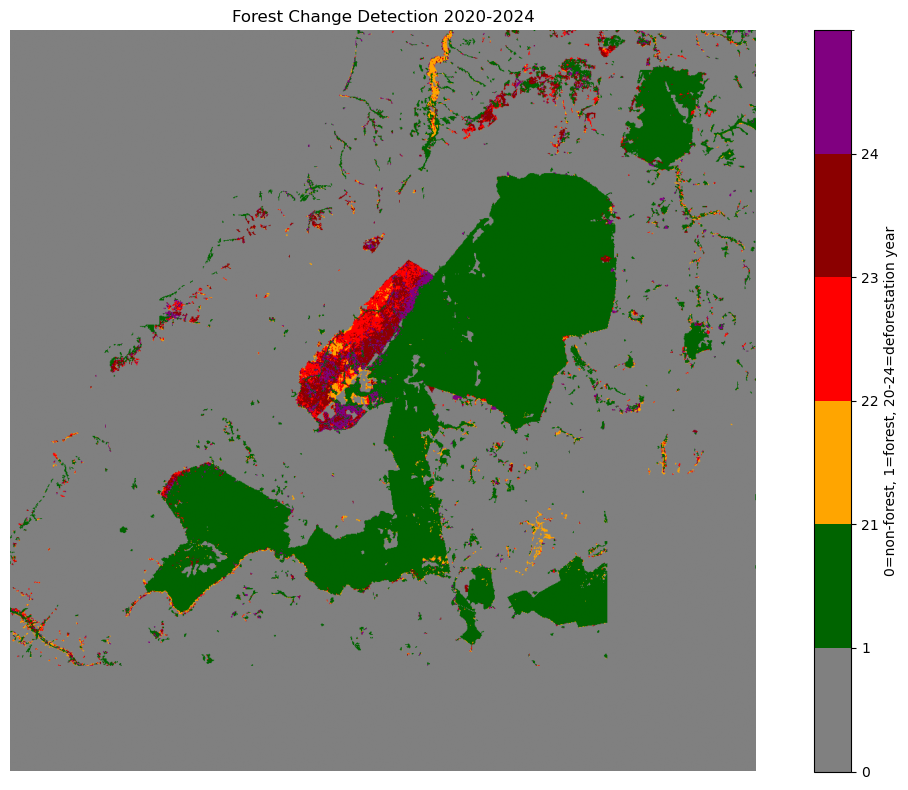

In [105]:
# Create colormap
plt.figure(figsize=(12, 8))

# Custom colors: gray (non-forest), green (forest), red gradient (deforestation years)
cmap = plt.cm.colors.ListedColormap(['gray', 'darkgreen', 'orange', 'red', 'darkred', 'black', 'purple'])
bounds = [0, 1, 21, 22, 23, 24, 25]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

im = plt.imshow(deforestation_map, cmap=cmap, norm=norm)
plt.colorbar(im, label='0=non-forest, 1=forest, 20-24=deforestation year', ticks=[0, 1, 21, 22, 23, 24])
plt.title('Forest Change Detection 2020-2024')
plt.axis('off')
plt.tight_layout()
plt.show()

In [106]:
# Export with LZW compression
output_dir = Path(base_path + "tess_deforestation")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / f"deforestation_map_tess_2020_2024_{defo_treeheight}m.tif"

with rasterio.open(treeheight_filepath) as src:
    with rasterio.open(output_path, 'w', driver='GTiff', height=src.height, 
                       width=src.width, count=1, dtype='int16', crs=src.crs, 
                       transform=src.transform, compress='lzw') as dst:
        dst.write(deforestation_map, 1)

print(f"Saved: {output_path}")

Saved: /home/georg/data/LEON_P6_forest-agri-change/tess_deforestation/deforestation_map_tess_2020_2024_6m.tif


# Assess S1 deforestation tracker to predicted tree height, Hansen and JRC_TMF

In [107]:
# ---------------- PATHS ----------------
s1_path     = Path(base_path) / "s1_deforested/s1_deforestation_year_20-25.tif"
th_path     = Path(base_path) / "tess_deforestation/deforestation_map_tess_2020_2024_6m.tif"
hansen_path = Path(base_path) / "Hansen/hansen_bugoma_32636.tif"
jrc_path    = Path(base_path) / "TMF/JRC_TMF_DeforestationYear_INT_1982_2025_v1_AFR_ID56_N10_E30.tif"

# ----------- LOAD S1 (REFERENCE GRID) -----------
with rasterio.open(s1_path) as src:
    s1_years      = src.read(1)
    dst_transform = src.transform
    dst_crs       = src.crs
    H, W          = src.height, src.width

s1       = s1_years > 0                                          # full 2020-2024 mask
s1_2023  = (s1_years >= 2020) & (s1_years <= 2023)              # restricted 2020-2023

print("S1 deforestation pixels (2020-2024):", s1.sum())
print("S1 deforestation pixels (2020-2023):", s1_2023.sum())

# ----------- REPROJECT INVALID MASK -----------
invalid_mask_s1 = np.zeros((H, W), dtype=np.uint8)
with rasterio.open(th_path) as src:
    reproject(
        source=invalid_mask.astype(np.uint8),
        destination=invalid_mask_s1,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
invalid_mask_s1 = invalid_mask_s1.astype(bool)

# ----------- LOAD & REPROJECT JRC TMF -----------
jrc_arr = np.zeros((H, W), dtype=np.int16)
with rasterio.open(jrc_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=jrc_arr,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
jrc_defor = (jrc_arr >= 2020) & (jrc_arr <= 2024)
print("JRC TMF deforestation pixels:", jrc_defor.sum())

# ----------- LOAD & REPROJECT TREEHEIGHT -----------
th_arr = np.zeros((H, W), dtype=np.uint8)
with rasterio.open(th_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=th_arr,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
treeheight_defor = (th_arr >= 20) & (th_arr <= 23)              # 2020-2023 only
print("Treeheight deforestation pixels:", treeheight_defor.sum())

# ----------- LOAD & REPROJECT HANSEN -----------
h_arr = np.zeros((H, W), dtype=np.uint8)
with rasterio.open(hansen_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=h_arr,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
hansen_defor = (h_arr >= 20) & (h_arr <= 24)
print("Hansen deforestation pixels:", hansen_defor.sum())

# ----------- APPLY VALID MASK -----------
valid_mask = ~invalid_mask_s1

s1_valid         = s1      & valid_mask
s1_valid_2023    = s1_2023 & valid_mask
hansen_valid     = hansen_defor     & valid_mask
jrc_valid        = jrc_defor        & valid_mask
treeheight_valid = treeheight_defor & valid_mask

# ---------------- METRICS FUNCTION ----------------
def compute_metrics(pred, ref):
    tp = int(np.sum(pred & ref))
    fp = int(np.sum(pred & ~ref))
    fn = int(np.sum(~pred & ref))
    tn = int(np.sum(~pred & ~ref))
    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return tp, fp, fn, tn, precision, recall, f1

# ---------------- COMPUTE COMPARISONS ----------------
tp_h, fp_h, fn_h, tn_h, p_h, r_h, f1_h = compute_metrics(s1_valid,      hansen_valid)
tp_j, fp_j, fn_j, tn_j, p_j, r_j, f1_j = compute_metrics(s1_valid,      jrc_valid)
tp_t, fp_t, fn_t, tn_t, p_t, r_t, f1_t = compute_metrics(s1_valid_2023, treeheight_valid)

# ---------------- PRINT METRICS ----------------
print("\n==== S1 (2020-2024) vs Hansen (valid only) ====")
print("TP:", tp_h, " FP:", fp_h, " FN:", fn_h, " TN:", tn_h)
print(f"Precision: {p_h:.1f}%  Recall: {r_h:.1f}%  F1: {f1_h:.1f}%")

print("\n==== S1 (2020-2024) vs JRC TMF (valid only) ====")
print("TP:", tp_j, " FP:", fp_j, " FN:", fn_j, " TN:", tn_j)
print(f"Precision: {p_j:.1f}%  Recall: {r_j:.1f}%  F1: {f1_j:.1f}%")

print("\n==== S1 (2020-2023) vs Treeheight (2020-2023, valid only) ====")
print("TP:", tp_t, " FP:", fp_t, " FN:", fn_t, " TN:", tn_t)
print(f"Precision: {p_t:.1f}%  Recall: {r_t:.1f}%  F1: {f1_t:.1f}%")

S1 deforestation pixels (2020-2024): 90868
S1 deforestation pixels (2020-2023): 77161
JRC TMF deforestation pixels: 57126
Treeheight deforestation pixels: 80811
Hansen deforestation pixels: 118460

==== S1 (2020-2024) vs Hansen (valid only) ====
TP: 61853  FP: 28112  FN: 55686  TN: 3605525
Precision: 68.8%  Recall: 52.6%  F1: 59.6%

==== S1 (2020-2024) vs JRC TMF (valid only) ====
TP: 36386  FP: 53579  FN: 20662  TN: 3640549
Precision: 40.4%  Recall: 63.8%  F1: 49.5%

==== S1 (2020-2023) vs Treeheight (2020-2023, valid only) ====
TP: 42382  FP: 33916  FN: 38429  TN: 3636449
Precision: 55.5%  Recall: 52.4%  F1: 54.0%


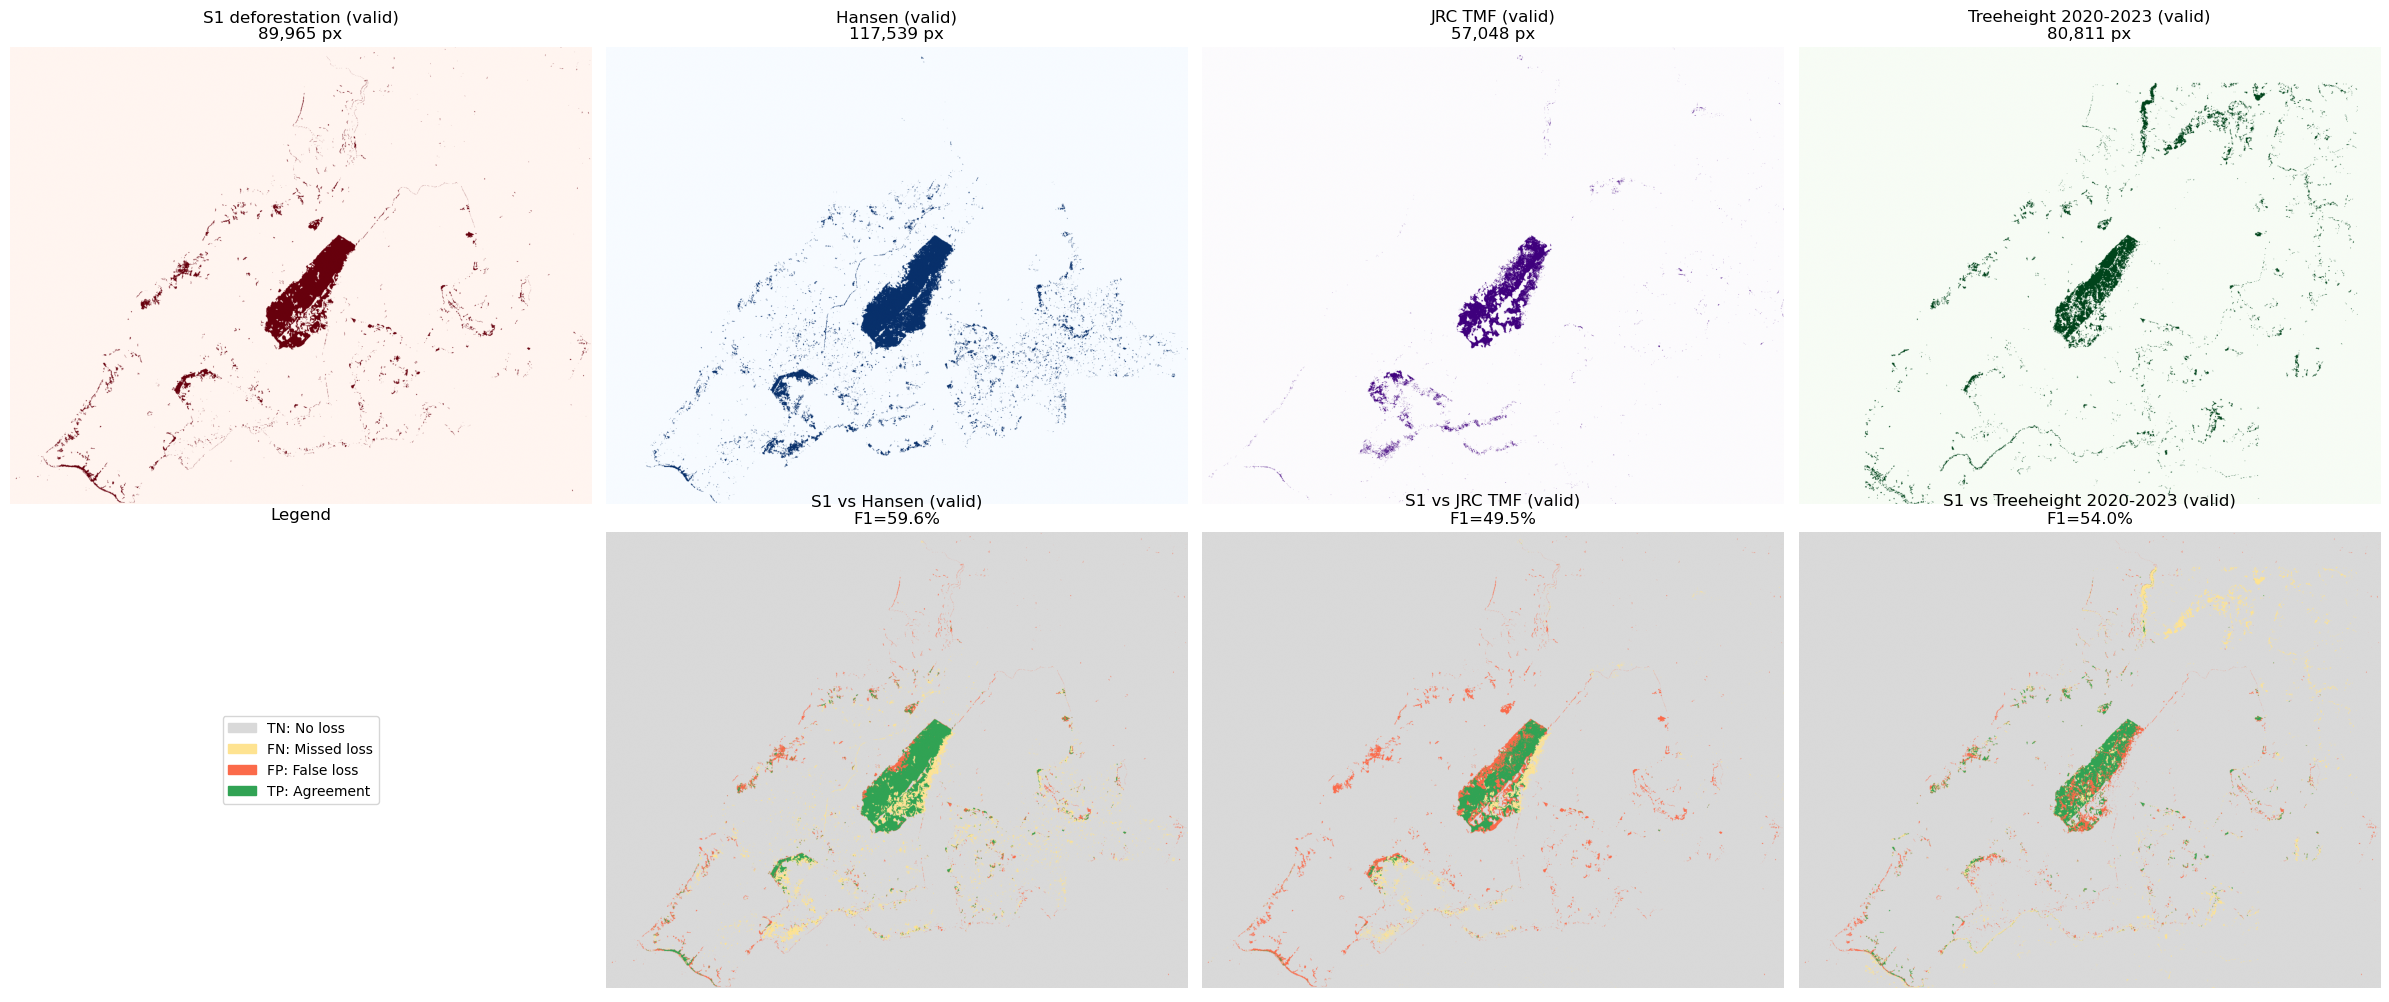

In [108]:
# ---------------- VISUALIZATION ----------------
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# ----------- ROW 1: raw masked layers -----------
axes[0,0].imshow(s1_valid, cmap="Reds")
axes[0,0].set_title(f"S1 deforestation (valid)\n{s1_valid.sum():,} px")
axes[0,0].axis("off")

axes[0,1].imshow(hansen_valid, cmap="Blues")
axes[0,1].set_title(f"Hansen (valid)\n{hansen_valid.sum():,} px")
axes[0,1].axis("off")

axes[0,2].imshow(jrc_valid, cmap="Purples")
axes[0,2].set_title(f"JRC TMF (valid)\n{jrc_valid.sum():,} px")
axes[0,2].axis("off")

axes[0,3].imshow(treeheight_valid, cmap="Greens")
axes[0,3].set_title(f"Treeheight 2020-2023 (valid)\n{treeheight_valid.sum():,} px")
axes[0,3].axis("off")

# ----------- AGREEMENT MAPS -----------
def make_agreement(pred, ref):
    out = np.zeros_like(pred, dtype=np.uint8)
    out[(~pred) & (~ref)] = 0
    out[(~pred) & (ref)]  = 1
    out[(pred)  & (~ref)] = 2
    out[(pred)  & (ref)]  = 3
    return out

agree_h = make_agreement(s1_valid,      hansen_valid)
agree_j = make_agreement(s1_valid,      jrc_valid)
agree_t = make_agreement(s1_valid_2023, treeheight_valid)  # year-restricted

cmap = ListedColormap(["#d9d9d9", "#fee391", "#fb6a4a", "#31a354"])

# Legend
legend = [
    Patch(color="#d9d9d9", label="TN: No loss"),
    Patch(color="#fee391", label="FN: Missed loss"),
    Patch(color="#fb6a4a", label="FP: False loss"),
    Patch(color="#31a354", label="TP: Agreement"),
]
axes[1,0].axis("off")
axes[1,0].legend(handles=legend, loc="center", fontsize=10)
axes[1,0].set_title("Legend")

# S1 vs Hansen
axes[1,1].imshow(agree_h, cmap=cmap, vmin=0, vmax=3)
axes[1,1].set_title(f"S1 vs Hansen (valid)\nF1={f1_h:.1f}%")
axes[1,1].axis("off")

# S1 vs JRC TMF
axes[1,2].imshow(agree_j, cmap=cmap, vmin=0, vmax=3)
axes[1,2].set_title(f"S1 vs JRC TMF (valid)\nF1={f1_j:.1f}%")
axes[1,2].axis("off")

# S1 vs Treeheight (year-restricted)
axes[1,3].imshow(agree_t, cmap=cmap, vmin=0, vmax=3)
axes[1,3].set_title(f"S1 vs Treeheight 2020-2023 (valid)\nF1={f1_t:.1f}%")
axes[1,3].axis("off")

plt.tight_layout()
plt.show()